In [ ]:
# importing lib.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\mymoviedb.csv", lineterminator='\n')
df.head()

In [ ]:
# viewing dataset info
df.info()

In [ ]:
• looks like our dataset has no NaNs! • Overview, Original_Language and Poster-Url
wouldn't be so useful during analysis • Release_Date column needs to be casted into
date time and to extract only the year value

In [ ]:
# exploring genres column
df['Genre'].head()

In [ ]:
• genres are saperated by commas followed by whitespaces.

In [ ]:
# check for duplicated rows
df.duplicated().sum()

In [ ]:
• our dataset has no duplicated rows either.

In [ ]:
# exploring summary statistics
df.describe()

In [ ]:
• Exploration Summary

• we have a dataframe consisting of 9827 rows and 9 columns.
• our dataset looks a bit tidy with no NaNs nor duplicated values.
• Release_Date column needs to be casted into date time and to extract only the
• Overview, Original_Languege and Poster-Url wouldn't be so useful during analys
• there is noticable outliers in Popularity column
• Vote_Average bettter be categorised for proper analysis.
• Genre column has comma saperated values and white spaces that needs to be hand

In [ ]:
# Data Cleaning

In [ ]:
Casting Release_Date column and extracing year values

In [ ]:
df.head()

In [ ]:
# casting column a
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
# confirming changes
print(df['Release_Date'].dtypes)

In [ ]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtypes

In [ ]:
df.info()

In [ ]:
df.head()

**Dropping Overview, Original_Languege
and Poster-Url**

In [ ]:
# making list of column to be dropped
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [ ]:
df.drop(cols, axis = 1, inplace = True)
df.columns

In [ ]:
df.head()

**categorizing Vote_Average column**

We would cut the Vote_Average values and make 4 categories: popular average
below_avg not_popular to describe it more using catigorize_col() function
provided above.

In [ ]:
def catigorize_col (df, col, labels):
 """
 catigorizes a certain column based on its quartiles

 Args:
 (df) df - dataframe we are proccesing
 (col) str - to be catigorized column's name
 (labels) list - list of labels from min to max

 Returns:
 (df) df - dataframe with the categorized col
 """

 # setting the edges to cut the column accordingly
 edges = [df[col].describe()['min'],
 df[col].describe()['25%'],
 df[col].describe()['50%'],
 df[col].describe()['75%'],
 df[col].describe()['max']]
 df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
 return df

In [ ]:
labels = ['not_popular', 'below_avg', 'average', 'popular']
# categorize column based on labels and edges
catigorize_col(df, 'Vote_Average', labels)
# confirming changes
df['Vote_Average'].unique()

In [ ]:
df.head()

In [ ]:
# exploring column
df['Vote_Average'].value_counts()

In [ ]:
# dropping NaNs
df.dropna(inplace = True)
# confirming
df.isna().sum()

In [ ]:
df.head()

In [ ]:
we'd split genres into a list and then explode our dataframe to have only one
genre per row for ezch movie

In [ ]:
# split the strings into lists
df['Genre'] = df['Genre'].str.split(', ')

# explode the lists
df = df.explode('Genre').reset_index(drop=True)
df.head()

In [ ]:
# casting column into category
df['Genre'] = df['Genre'].astype('category')

# confirming changes
df['Genre'].dtypes

In [ ]:
df.info()

In [ ]:
df.nunique()

**Data Visualization**

here, we'd use Matplotlib and seaborn for making some informative visuals to gain
insights abut our data.

In [ ]:
# setting up seaborn configurations
sns.set_style('whitegrid')

In [ ]:
#Q1: What is the most frequent genre in the dataset?

In [28]:
# showing stats. on genre column
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

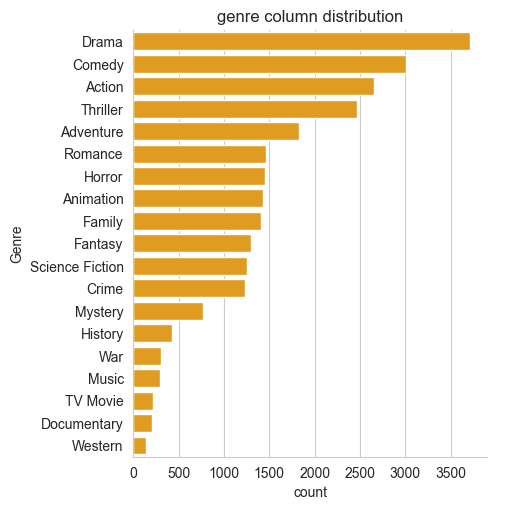

In [31]:
# visualizing genre column
sns.catplot(y = 'Genre', data = df, kind = 'count',
 order = df['Genre'].value_counts().index,
 color = 'orange')
plt.title('genre column distribution')
plt.show()

In [ ]:
we can notice from the above visual that Drama genre is the most frequent genre
in our dataset and has appeared more than 14% of the times among 19 other
genres.

In [ ]:
Q2: What genres has highest votes ?

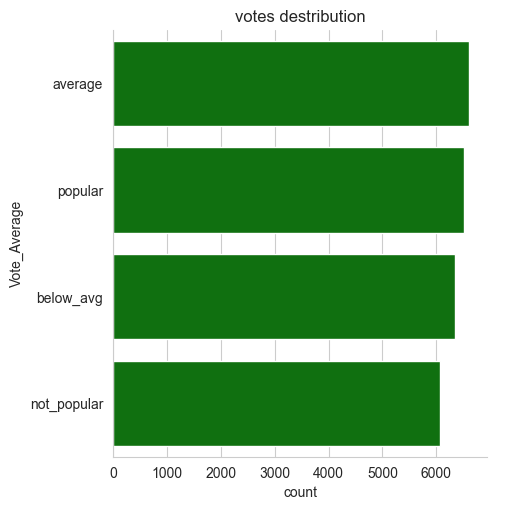

In [33]:
# visualizing vote_average column
sns.catplot(y = 'Vote_Average', data = df, kind = 'count',
 order = df['Vote_Average'].value_counts().index,
 color = 'green')
plt.title('votes destribution')
plt.show()

In [ ]:
Q3: What movie got the highest popularity ? what's its genre ?

In [34]:
# checking max popularity in dataset
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


In [ ]:
Q4: What movie got the lowest popularity? what's its genre?

In [35]:
# checking max popularity in dataset
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


In [ ]:
Q5: Which year has the most filmmed movies?

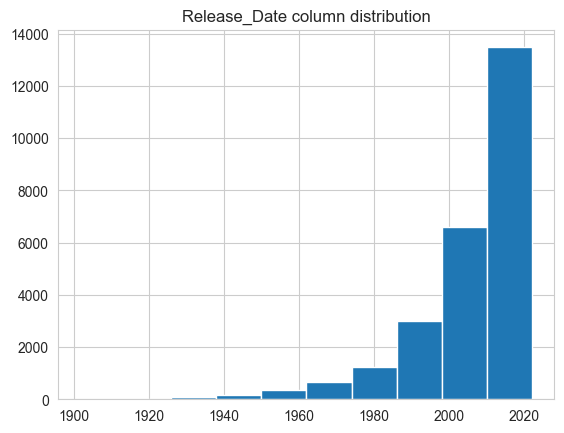

In [36]:
df['Release_Date'].hist()
plt.title('Release_Date column distribution')
plt.show()

**Conclusion**

In [ ]:
Q1: What is the most frequent genre in the dataset?
Drama genre is the most frequent genre in our dataset and has appeared more than
14% of the times among 19 other genres.
    
Q2: What genres has highest votes ?
we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
highest popularity among fans by being having more than 18.5% of movies popularities.
    
Q3: What movie got the highest popularity ? what's its genre ?
Spider-Man: No Way Home has the highest popularity rate in our dataset and it hagenres of Action , Adventure and Sience Fiction .
    
Q3: What movie got the lowest popularity ? what's its genre ?
The united states, thread' has the highest lowest rate in our dataset
and it has genres of music , drama , 'war', 'sci-fi' and history`.
    
Q4: Which year has the most filmmed movies?
year 2020 has the highest filmming rate in our dataset.
